# KMeans

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

plt.style.use('ggplot')


In [ ]:
# %% [markdown]
# ## 1. Clustering con K-Means

# %% [code]
# Generar datos sintéticos (3 clusters bien definidos)
X1, y1 = make_blobs(
    n_samples=500,
    centers=3,
    cluster_std=0.8,
    random_state=42
)

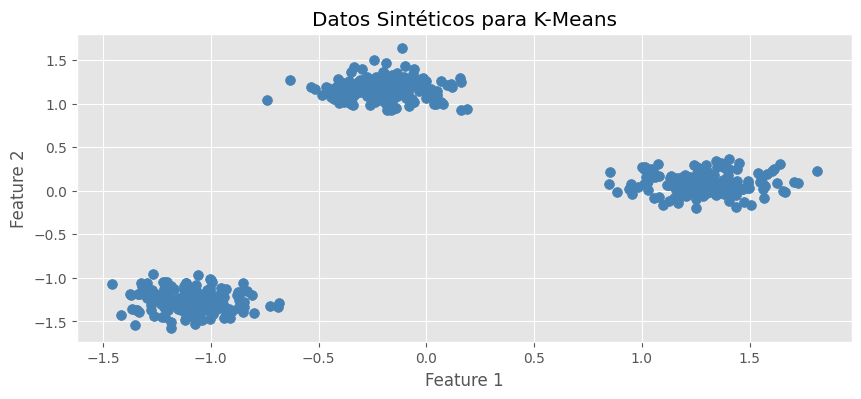

In [ ]:
# Estandarizar datos
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)

# Visualizar datos crudos
plt.figure(figsize=(10, 4))
plt.scatter(X1_scaled[:, 0], X1_scaled[:, 1], c='steelblue', s=50)
plt.title("Datos Sintéticos para K-Means")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Inercia (K-Means): 20.43
Coeficiente de Silueta: 0.88


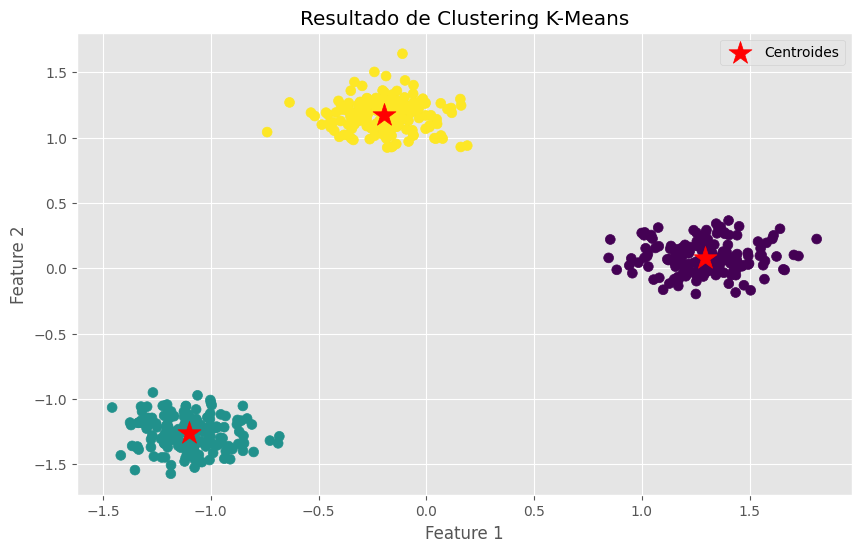

In [ ]:
# %% [code]
# Aplicar K-Means
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    random_state=42
)
kmeans.fit(X1_scaled)
labels_kmeans = kmeans.labels_

# Métricas de evaluación
silhouette = silhouette_score(X1_scaled, labels_kmeans)

# Resultados
print(f"Inercia (K-Means): {inertia:.2f}")
print(f"Coeficiente de Silueta: {silhouette:.2f}")

# %% [code]
# Visualizar clusters
plt.figure(figsize=(10, 6))
plt.scatter(
    X1_scaled[:, 0],
    X1_scaled[:, 1],
    c=labels_kmeans,
    cmap='viridis',
    s=50
)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    marker='*',
    c='red',
    label='Centroides'
)
plt.title("Resultado de Clustering K-Means")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [ ]:
legir la cantidad de clusters en clustering
La elección del número de clusters es un desafío fundamental en clustering. Aquí te presento los métodos principales con implementación práctica

1. Método del Codo (Elbow Method) para K-Means

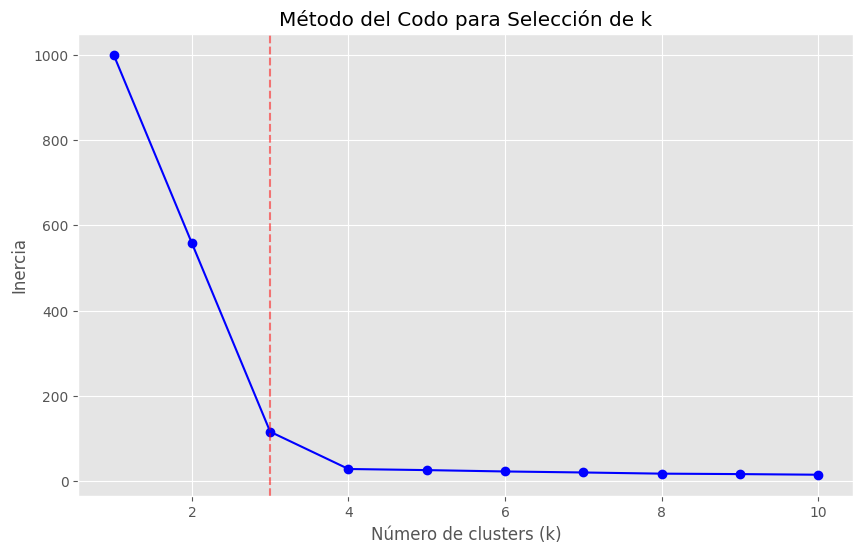

In [ ]:
from sklearn.cluster import KMeans

# Generar datos
X, _ = make_blobs(n_samples=500, centers=4, random_state=42)
X = StandardScaler().fit_transform(X)

# Calcular inercia para diferentes valores de k
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Graficar método del codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para Selección de k')
plt.axvline(x=3, color='r', linestyle='--', alpha=0.5)
plt.grid(True)
plt.show()

. Coeficiente de Silueta

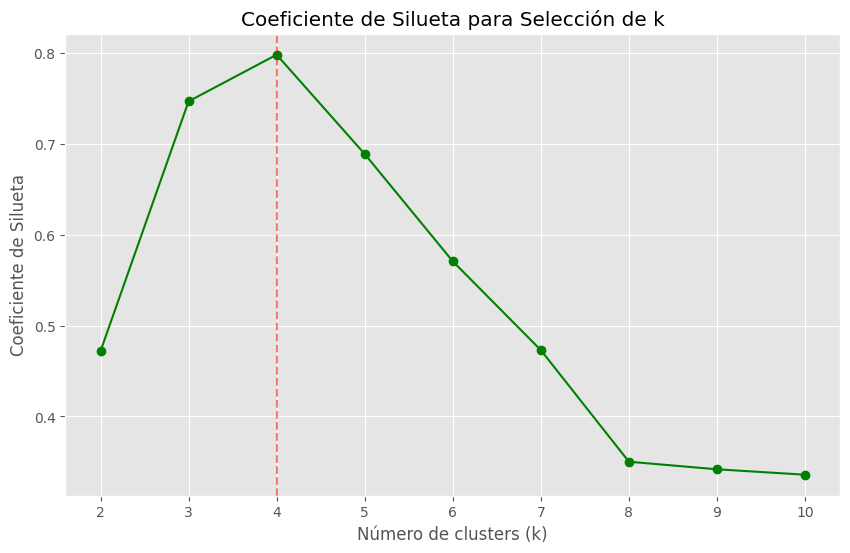

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Graficar coeficiente de silueta
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'go-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Coeficiente de Silueta')
plt.title('Coeficiente de Silueta para Selección de k')
plt.axvline(x=np.argmax(silhouette_scores) + 2, color='r', linestyle='--', alpha=0.5)
plt.grid(True)
plt.show()

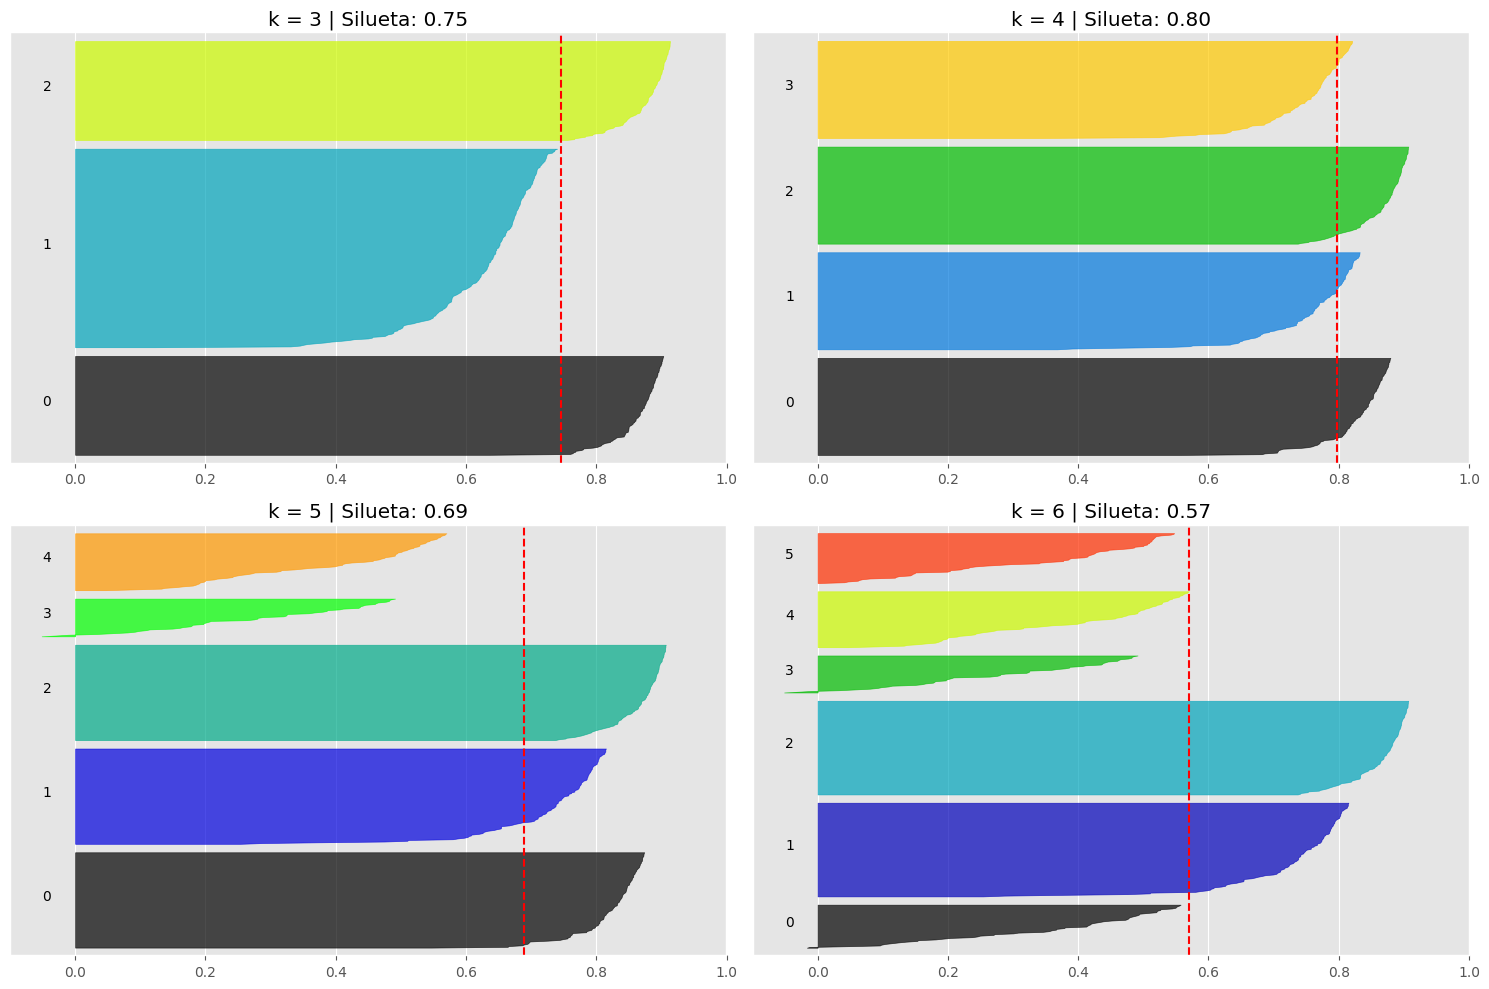

In [ ]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

plt.figure(figsize=(15, 10))
k_range = [3, 4, 5, 6]

for i, k in enumerate(k_range):
    plt.subplot(2, 2, i+1)

    # Clusterización y cálculo de siluetas
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    silhouette_avg = silhouette_score(X, labels)
    sample_silhouette_values = silhouette_samples(X, labels)

    y_lower = 10
    colors = cm.nipy_spectral(labels.astype(float) / k)

    for j in range(k):
        # Agrupar valores de silueta por cluster
        jth_values = sample_silhouette_values[labels == j]
        jth_values.sort()

        size_j = jth_values.shape[0]
        y_upper = y_lower + size_j

        color = cm.nipy_spectral(float(j) / k)
        plt.fill_betweenx(np.arange(y_lower, y_upper),
                          0, jth_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        plt.text(-0.05, y_lower + 0.5 * size_j, str(j))
        y_lower = y_upper + 10

    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.title(f"k = {k} | Silueta: {silhouette_avg:.2f}")
    plt.yticks([])
    plt.xlim([-0.1, 1])
    plt.ylim([0, len(X) + (k + 1) * 10])

plt.tight_layout()
plt.show()